## Comparing the fitted parameters of the different Transfer Function (FS and RS neurons).

Ilaria Carannante

mailto: ilaria.carannante@cnrs.fr, ilariac@kth.se
NeuroPSI, ICN, Saclay, France

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt

from utils.Plots_helper import *
from sklearn.decomposition import PCA

In [2]:
import os
# Setting file saving
figs = []
fig_path = os.path.join('figures')
isExist = os.path.exists(fig_path)
if not isExist:
   os.makedirs(fig_path)
   print('The directory "figures" is created.')

def save_figs(fig_path, name, figs):
    pdf_file_path = os.path.join(fig_path, name + '-figs.pdf')
    with PdfPages(pdf_file_path) as ofile:
        for fig in figs:
            ofile.savefig(fig) 

fig_name = 'Comparing_TF_fitted_params_FS_RS_full_range'

In [3]:
# Load
with open("full_range/alpha_results_TF_FS_v1_best_10.json", "r") as f:
    data = json.load(f)

# Extract into arrays
alphas = np.array([d["alpha"] for d in data])
errors = np.array([d["mean_error"] for d in data])
poly_params_FS = np.array([d["polynomial_params"] for d in data])  # shape: (n_models, 10)

n_models, n_params = poly_params_FS.shape
#print(poly_params_FS.shape)
means_FS = poly_params_FS.mean(axis=0)
stds_FS  = poly_params_FS.std(axis=0)
poly_z_FS = (poly_params_FS - means_FS) / stds_FS

# Load
#with open("results_RS_no_adapt_best_20.json", "r") as f:
with open("full_range/alpha_results_TF_RS_no_adapt_v1_best_10.json", "r") as f:
    data = json.load(f)

# Extract into arrays
alphas = np.array([d["alpha"] for d in data])
errors = np.array([d["mean_error"] for d in data])
poly_params_RS_no_adapt = np.array([d["polynomial_params"] for d in data])  # shape: (n_models, 10)

n_models, n_params = poly_params_RS_no_adapt.shape
#print(poly_params_RS.shape)
means_RS_no_adapt = poly_params_RS_no_adapt.mean(axis=0)
stds_RS_no_adapt  = poly_params_RS_no_adapt.std(axis=0)
poly_z_RS_no_adapt = (poly_params_RS_no_adapt - means_RS_no_adapt) / stds_RS_no_adapt


# Load
with open("full_range/alpha_results_TF_RS_delay_v1_best_10.json", "r") as f:
    data = json.load(f)

# Extract into arrays
alphas = np.array([d["alpha"] for d in data])
errors = np.array([d["mean_error"] for d in data])
poly_params_RS = np.array([d["polynomial_params"] for d in data])  # shape: (n_models, 10)

n_models, n_params = poly_params_RS.shape
#print(poly_params_RS.shape)
means_RS = poly_params_RS.mean(axis=0)
stds_RS  = poly_params_RS.std(axis=0)
poly_z_RS = (poly_params_RS - means_RS) / stds_RS

In [4]:
params_name = ['P_0', 'P_mu', 'P_sig', 'P_tau', 'P_mu2', 'P_sig2', 'P_tau2', 'P_mu_sig', 'P_mu_tau', 'P_sig_tau']

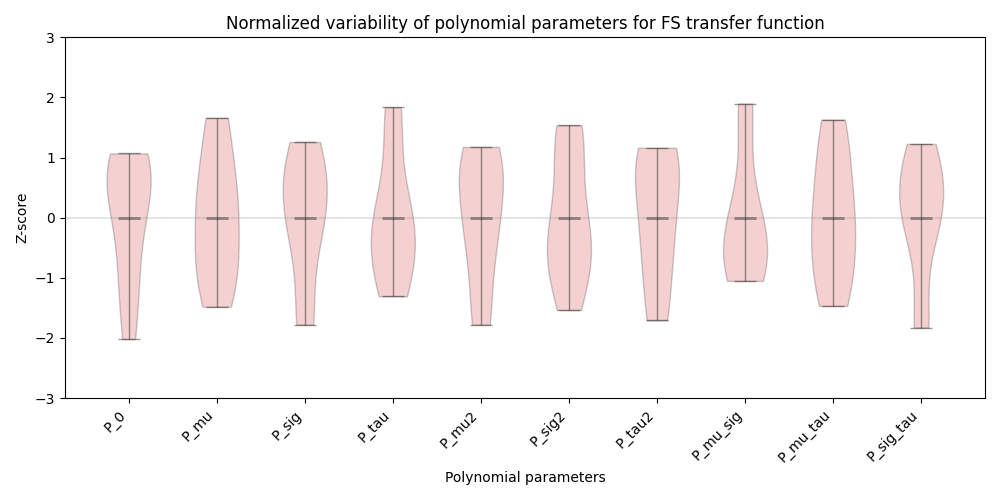

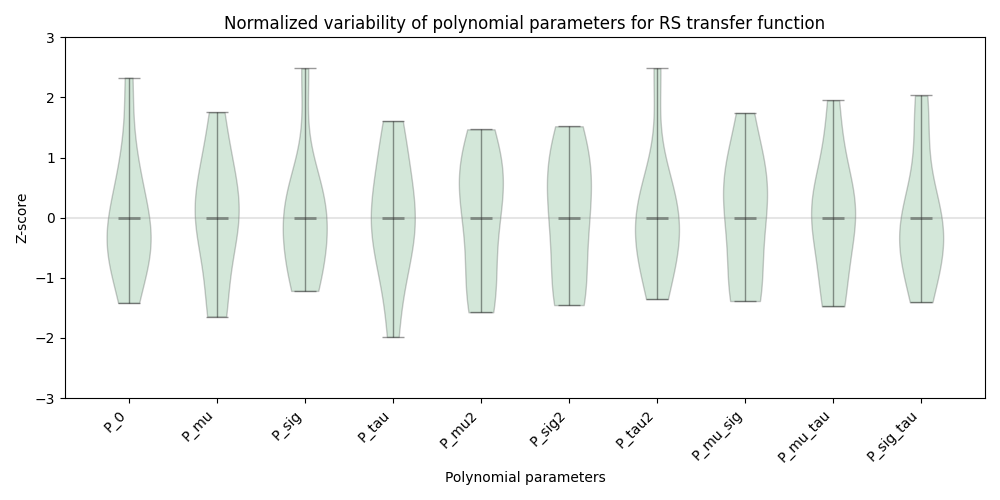

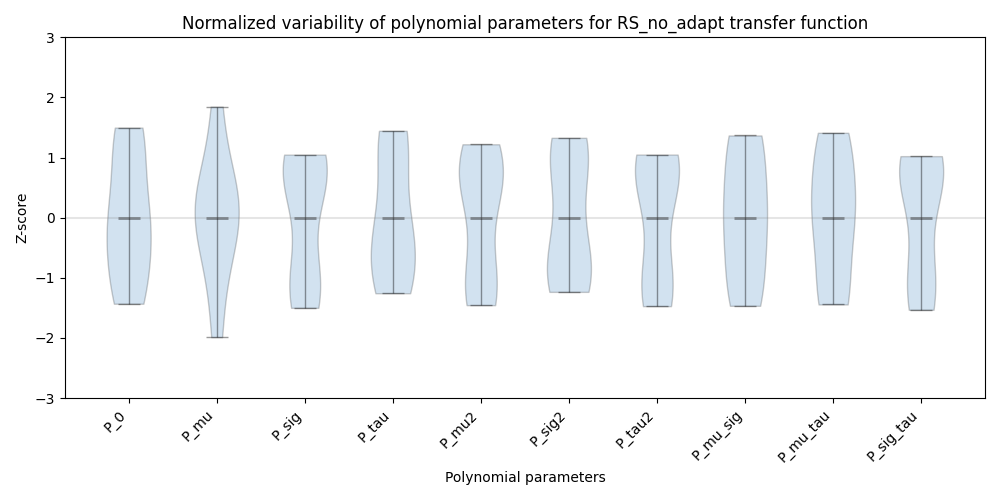

In [5]:
fig_violin = plot_violin('FS', poly_z_FS, params_name)
figs.append(fig_violin)
fig_violin = plot_violin('RS', poly_z_RS, params_name)
figs.append(fig_violin)
fig_violin = plot_violin('RS_no_adapt', poly_z_RS_no_adapt, params_name)
figs.append(fig_violin)

In [6]:
pca_FS = PCA()
X_pca_FS = pca_FS.fit_transform(poly_params_FS)
expl_var_FS = pca_FS.explained_variance_ratio_
cum_var_FS  = np.cumsum(expl_var_FS)

pca_RS_no_adapt = PCA()
X_pca_RS_no_adapt = pca_RS_no_adapt.fit_transform(poly_params_RS_no_adapt)
expl_var_RS_no_adapt = pca_RS_no_adapt.explained_variance_ratio_
cum_var_RS_no_adapt  = np.cumsum(expl_var_RS_no_adapt)

pca_RS = PCA()
X_pca_RS = pca_RS.fit_transform(poly_params_RS)
expl_var_RS = pca_RS.explained_variance_ratio_
cum_var_RS  = np.cumsum(expl_var_RS)

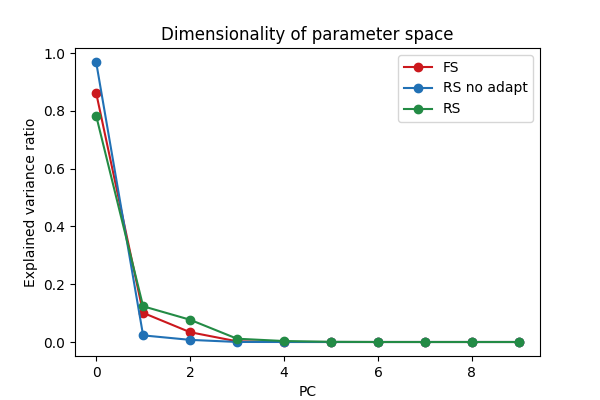

In [7]:
fig = plt.figure(figsize=(6,4))
plt.plot(expl_var_FS, 'o-', color=color_palette["FS"], label='FS')
plt.plot(expl_var_RS_no_adapt, 'o-', color=color_palette["RS_no_adapt"], label='RS no adapt')
plt.plot(expl_var_RS, 'o-', color=color_palette["RS"], label='RS')

plt.xlabel("PC")
plt.ylabel("Explained variance ratio")
plt.title("Dimensionality of parameter space")
plt.legend()

figs.append(fig)

In [8]:
print(f'FS: PC1 and PC2 explain {((expl_var_FS[0]+expl_var_FS[1]) * 100):.2f}% of the variance!')
print(f'RS no adapt: PC1 and PC2 explain {((expl_var_RS_no_adapt[0]+expl_var_RS_no_adapt[1]) * 100):.2f}% of the variance!')
print(f'RS: PC1 and PC2 explain {((expl_var_RS[0]+expl_var_RS[1]) * 100):.2f}% of the variance!')

FS: PC1 and PC2 explain 96.37% of the variance!
RS no adapt: PC1 and PC2 explain 99.25% of the variance!
RS: PC1 and PC2 explain 90.76% of the variance!


In [9]:
print(f'FS: PC1, PC2 and PC3 explain {((expl_var_FS[0]+expl_var_FS[1]+expl_var_FS[2]) * 100):.2f}% of the variance!')
print(f'RS no adapt: PC1, PC2 and PC3 explain {((expl_var_RS_no_adapt[0]+expl_var_RS_no_adapt[1]+expl_var_RS_no_adapt[2]) * 100):.2f}% of the variance!')
print(f'RS: PC1, PC2 and PC3 explain {((expl_var_RS[0]+expl_var_RS[1]+expl_var_RS[2]) * 100):.2f}% of the variance!')

FS: PC1, PC2 and PC3 explain 99.76% of the variance!
RS no adapt: PC1, PC2 and PC3 explain 99.99% of the variance!
RS: PC1, PC2 and PC3 explain 98.46% of the variance!


In [10]:
loadings_values_FS = pd.DataFrame(
    pca_FS.components_[:3],   # only PC1, PC2, and PC3
    columns=params_name,
    index=['PC1', 'PC2', 'PC3']
)

print(loadings_values_FS)

          P_0      P_mu     P_sig     P_tau     P_mu2    P_sig2    P_tau2  \
PC1  0.002540  0.023754 -0.289038  0.127454 -0.005042  0.135412 -0.666470   
PC2  0.003661 -0.018953  0.090206 -0.007392  0.002524  0.843841  0.431316   
PC3  0.018627 -0.010659 -0.139705  0.158488  0.002080 -0.499697  0.585848   

     P_mu_sig  P_mu_tau  P_sig_tau  
PC1  0.019722 -0.021447  -0.660491  
PC2  0.013719 -0.044281  -0.301959  
PC3  0.022396 -0.015383  -0.601038  


In [11]:
for pc in ['PC1', 'PC2', 'PC3']:
    print(f"\nTop contributors to {pc}")
    print(loadings_values_FS.loc[pc].abs().sort_values(ascending=False))


Top contributors to PC1
P_tau2       0.666470
P_sig_tau    0.660491
P_sig        0.289038
P_sig2       0.135412
P_tau        0.127454
P_mu         0.023754
P_mu_tau     0.021447
P_mu_sig     0.019722
P_mu2        0.005042
P_0          0.002540
Name: PC1, dtype: float64

Top contributors to PC2
P_sig2       0.843841
P_tau2       0.431316
P_sig_tau    0.301959
P_sig        0.090206
P_mu_tau     0.044281
P_mu         0.018953
P_mu_sig     0.013719
P_tau        0.007392
P_0          0.003661
P_mu2        0.002524
Name: PC2, dtype: float64

Top contributors to PC3
P_sig_tau    0.601038
P_tau2       0.585848
P_sig2       0.499697
P_tau        0.158488
P_sig        0.139705
P_mu_sig     0.022396
P_0          0.018627
P_mu_tau     0.015383
P_mu         0.010659
P_mu2        0.002080
Name: PC3, dtype: float64


In [12]:
loadings_values_RS_no_adapt = pd.DataFrame(
    pca_RS_no_adapt.components_[:3],   # only PC1, PC2, and PC3
    columns=params_name,
    index=['PC1', 'PC2', 'PC3']
)

print(loadings_values_RS_no_adapt)

          P_0      P_mu     P_sig     P_tau     P_mu2    P_sig2    P_tau2  \
PC1  0.013373  0.009951 -0.268974  0.163176 -0.003852  0.201611 -0.567676   
PC2 -0.070523  0.047213  0.189850 -0.437200 -0.000404 -0.083774  0.522388   
PC3  0.030166 -0.042828  0.031441  0.111051  0.005182  0.919132  0.341680   

     P_mu_sig  P_mu_tau  P_sig_tau  
PC1  0.026936 -0.064527  -0.730028  
PC2 -0.120483  0.279749  -0.626839  
PC3  0.072656 -0.129775   0.015473  


In [13]:
for pc in ['PC1', 'PC2', 'PC3']:
    print(f"\nTop contributors to {pc}")
    print(loadings_values_RS_no_adapt.loc[pc].abs().sort_values(ascending=False))


Top contributors to PC1
P_sig_tau    0.730028
P_tau2       0.567676
P_sig        0.268974
P_sig2       0.201611
P_tau        0.163176
P_mu_tau     0.064527
P_mu_sig     0.026936
P_0          0.013373
P_mu         0.009951
P_mu2        0.003852
Name: PC1, dtype: float64

Top contributors to PC2
P_sig_tau    0.626839
P_tau2       0.522388
P_tau        0.437200
P_mu_tau     0.279749
P_sig        0.189850
P_mu_sig     0.120483
P_sig2       0.083774
P_0          0.070523
P_mu         0.047213
P_mu2        0.000404
Name: PC2, dtype: float64

Top contributors to PC3
P_sig2       0.919132
P_tau2       0.341680
P_mu_tau     0.129775
P_tau        0.111051
P_mu_sig     0.072656
P_mu         0.042828
P_sig        0.031441
P_0          0.030166
P_sig_tau    0.015473
P_mu2        0.005182
Name: PC3, dtype: float64


In [14]:
loadings_values_RS = pd.DataFrame(
    pca_RS.components_[:3],   # only PC1, PC2, and PC3
    columns=params_name,
    index=['PC1', 'PC2', 'PC3']
)

print(loadings_values_RS)

          P_0      P_mu     P_sig     P_tau     P_mu2    P_sig2    P_tau2  \
PC1 -0.030948  0.008144  0.260461 -0.395530  0.003476  0.038486  0.852637   
PC2 -0.083243 -0.020688 -0.180667 -0.218057  0.004825  0.143794  0.101777   
PC3 -0.189927 -0.095903 -0.139616 -0.717952  0.016498  0.355158 -0.403373   

     P_mu_sig  P_mu_tau  P_sig_tau  
PC1 -0.025400  0.135725  -0.164749  
PC2  0.037787  0.145243   0.926753  
PC3 -0.028798  0.245692  -0.263570  


In [15]:
for pc in ['PC1', 'PC2', 'PC3']:
    print(f"\nTop contributors to {pc}")
    print(loadings_values_RS_no_adapt.loc[pc].abs().sort_values(ascending=False))


Top contributors to PC1
P_sig_tau    0.730028
P_tau2       0.567676
P_sig        0.268974
P_sig2       0.201611
P_tau        0.163176
P_mu_tau     0.064527
P_mu_sig     0.026936
P_0          0.013373
P_mu         0.009951
P_mu2        0.003852
Name: PC1, dtype: float64

Top contributors to PC2
P_sig_tau    0.626839
P_tau2       0.522388
P_tau        0.437200
P_mu_tau     0.279749
P_sig        0.189850
P_mu_sig     0.120483
P_sig2       0.083774
P_0          0.070523
P_mu         0.047213
P_mu2        0.000404
Name: PC2, dtype: float64

Top contributors to PC3
P_sig2       0.919132
P_tau2       0.341680
P_mu_tau     0.129775
P_tau        0.111051
P_mu_sig     0.072656
P_mu         0.042828
P_sig        0.031441
P_0          0.030166
P_sig_tau    0.015473
P_mu2        0.005182
Name: PC3, dtype: float64


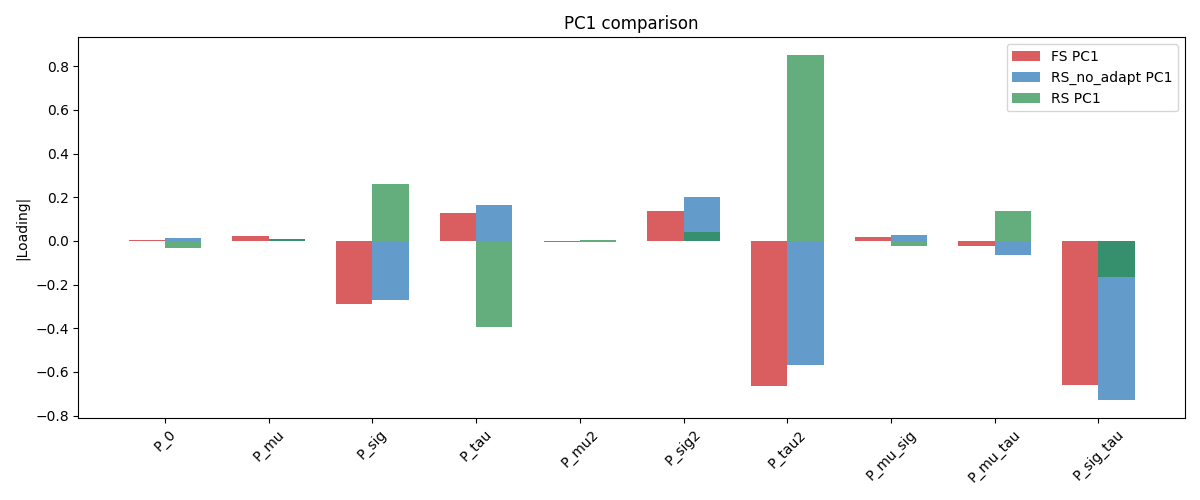

In [16]:
width = 0.35
x = np.arange(len(params_name))

fig = plt.figure(figsize=(12,5))

plt.bar(x - width/2, loadings_values_FS.loc['PC1'],
        width, label='FS PC1', color=color_palette["FS"], alpha=0.7)

plt.bar(x + width/2, loadings_values_RS_no_adapt.loc['PC1'],
        width, label='RS_no_adapt PC1', color=color_palette["RS_no_adapt"], alpha=0.7)

plt.bar(x + width/2, loadings_values_RS.loc['PC1'],
        width, label='RS PC1', color=color_palette["RS"], alpha=0.7)
plt.xticks(x, params_name, rotation=45)
plt.ylabel("|Loading|")
plt.title("PC1 comparison")
plt.legend()
plt.tight_layout()

figs.append(fig)

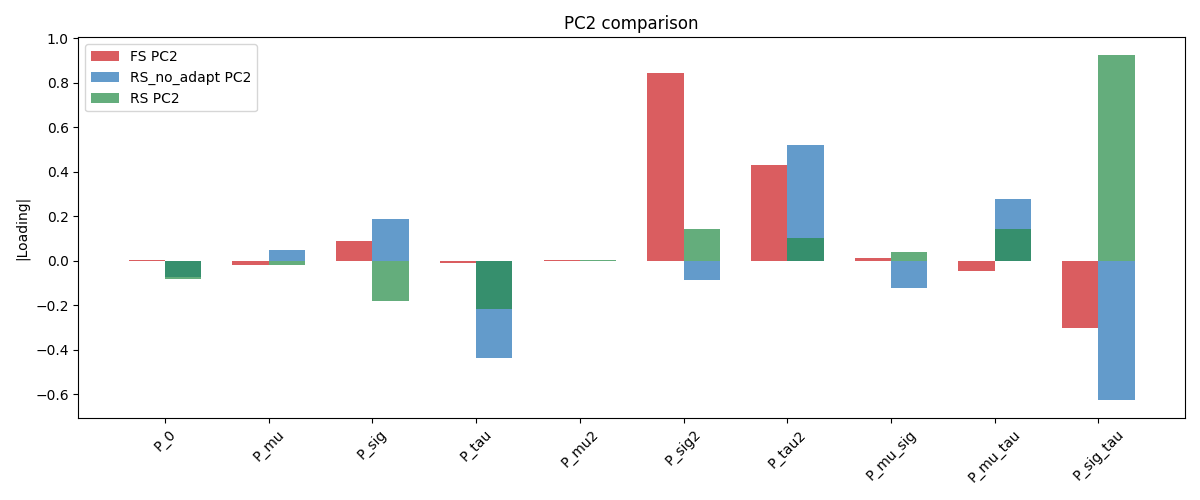

In [17]:
fig = plt.figure(figsize=(12,5))

plt.bar(x - width/2, loadings_values_FS.loc['PC2'],
        width, label='FS PC2', color=color_palette["FS"], alpha=0.7)

plt.bar(x + width/2, loadings_values_RS_no_adapt.loc['PC2'],
        width, label='RS_no_adapt PC2', color=color_palette["RS_no_adapt"], alpha=0.7)

plt.bar(x + width/2, loadings_values_RS.loc['PC2'],
        width, label='RS PC2', color=color_palette["RS"], alpha=0.7)


plt.xticks(x, params_name, rotation=45)
plt.ylabel("|Loading|")
plt.title("PC2 comparison")
plt.legend()
plt.tight_layout()

figs.append(fig)

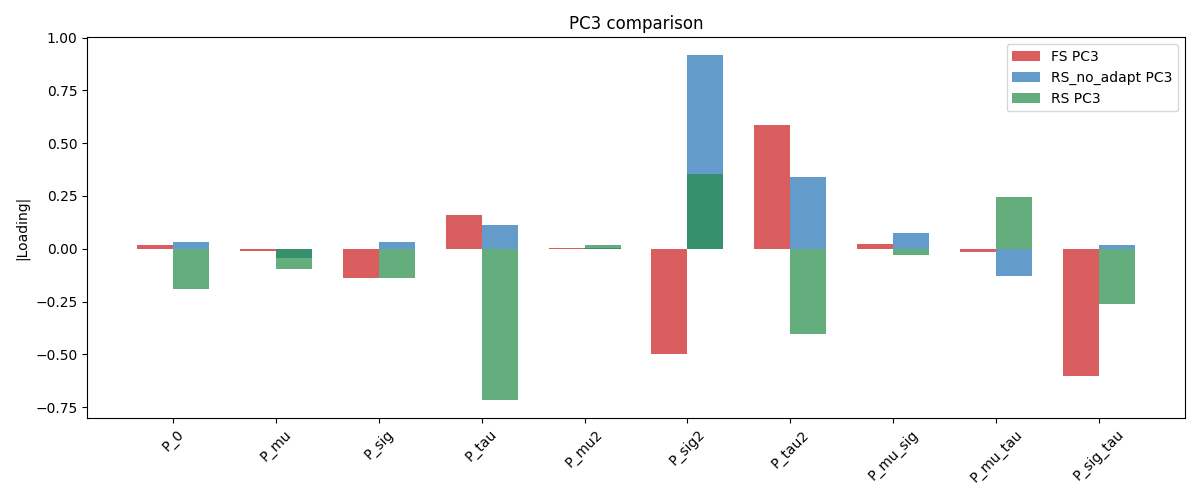

In [18]:
fig = plt.figure(figsize=(12,5))

plt.bar(x - width/2, loadings_values_FS.loc['PC3'],
        width, label='FS PC3', color=color_palette["FS"], alpha=0.7)

plt.bar(x + width/2, loadings_values_RS_no_adapt.loc['PC3'],
        width, label='RS_no_adapt PC3', color=color_palette["RS_no_adapt"], alpha=0.7)

plt.bar(x + width/2, loadings_values_RS.loc['PC3'],
        width, label='RS PC3', color=color_palette["RS"], alpha=0.7)


plt.xticks(x, params_name, rotation=45)
plt.ylabel("|Loading|")
plt.title("PC3 comparison")
plt.legend()
plt.tight_layout()

figs.append(fig)

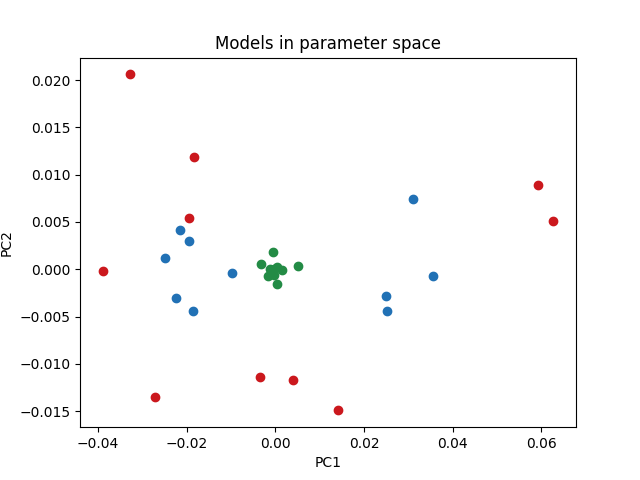

In [19]:
fig = plt.figure()
plt.scatter(X_pca_FS[:,0], X_pca_FS[:,1], c=color_palette['FS'])
plt.scatter(X_pca_RS[:,0], X_pca_RS[:,1], c=color_palette['RS'])
plt.scatter(X_pca_RS_no_adapt[:,0], X_pca_RS_no_adapt[:,1], c=color_palette['RS_no_adapt'])

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Models in parameter space")
figs.append(fig)

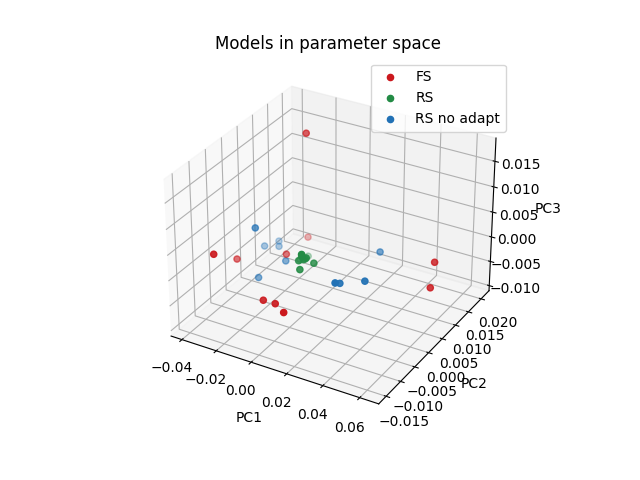

In [20]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed to activate 3D)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_pca_FS[:, 0], X_pca_FS[:, 1], X_pca_FS[:, 2],
    c=color_palette['FS'], label='FS'
)
ax.scatter(
    X_pca_RS[:, 0], X_pca_RS[:, 1], X_pca_RS[:, 2],
    c=color_palette['RS'], label='RS'
)
ax.scatter(
    X_pca_RS_no_adapt[:, 0], X_pca_RS_no_adapt[:, 1], X_pca_RS_no_adapt[:, 2],
    c=color_palette['RS_no_adapt'], label='RS no adapt'
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("Models in parameter space")

ax.legend()
figs.append(fig)

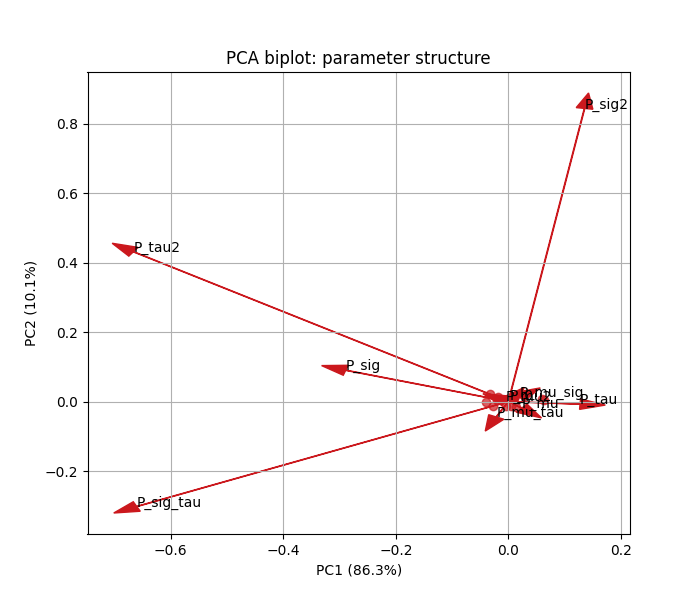

In [21]:
fig = plt.figure(figsize=(7,6))
plt.scatter(X_pca_FS[:,0], X_pca_FS[:,1], color = color_palette['FS'], alpha=0.7)
loadings_FS = pca_FS.components_
for i in range(n_params):
    plt.arrow(0, 0,
              loadings_FS[0,i],
              loadings_FS[1,i],
              head_width=0.03,
              color = color_palette['FS'])
    plt.text(loadings_FS[0,i],
             loadings_FS[1,i],
             f"{params_name[i]}")

plt.xlabel(f"PC1 ({expl_var_FS[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({expl_var_FS[1]*100:.1f}%)")
plt.title("PCA biplot: parameter structure")
plt.grid()
figs.append(fig)

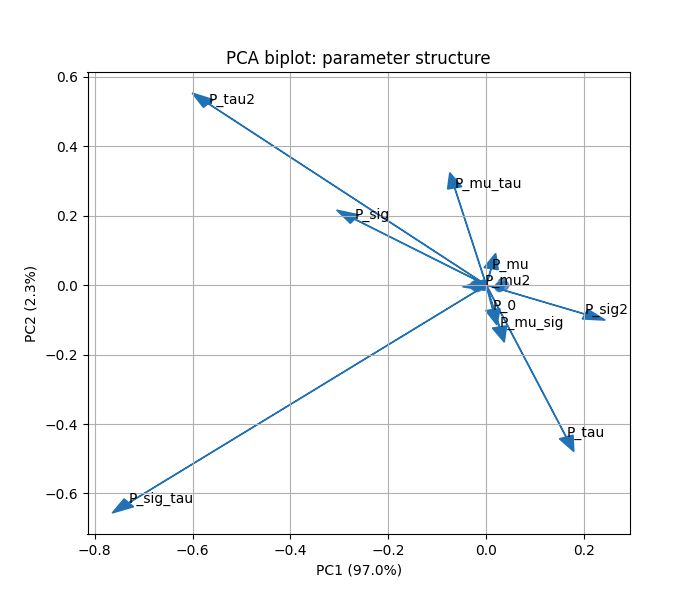

In [22]:
fig = plt.figure(figsize=(7,6))
plt.scatter(X_pca_RS_no_adapt[:,0], X_pca_RS_no_adapt[:,1], color = color_palette['RS_no_adapt'], alpha=0.7)
loadings_RS_no_adapt = pca_RS_no_adapt.components_
for i in range(n_params):
    plt.arrow(0, 0,
              loadings_RS_no_adapt[0,i],
              loadings_RS_no_adapt[1,i],
              head_width=0.03,
              color = color_palette['RS_no_adapt'])
    plt.text(loadings_RS_no_adapt[0,i],
             loadings_RS_no_adapt[1,i],
             f"{params_name[i]}")

plt.xlabel(f"PC1 ({expl_var_RS_no_adapt[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({expl_var_RS_no_adapt[1]*100:.1f}%)")
plt.title("PCA biplot: parameter structure")
plt.grid()
figs.append(fig)

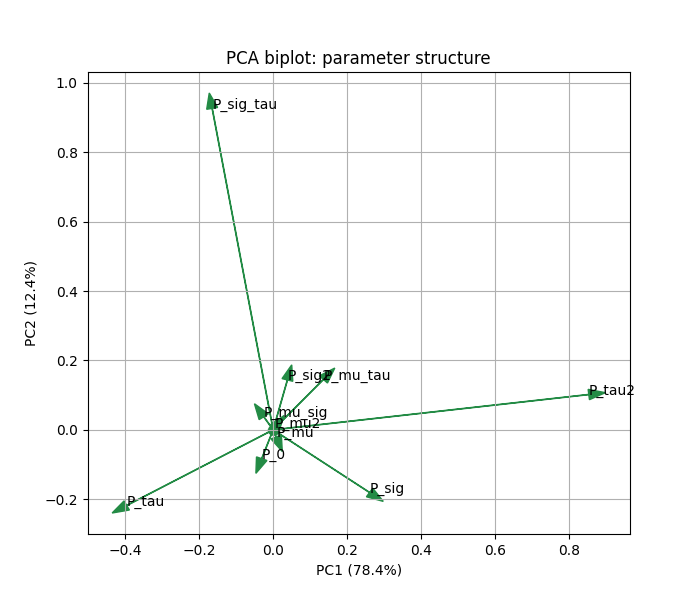

In [23]:
fig = plt.figure(figsize=(7,6))
plt.scatter(X_pca_RS[:,0], X_pca_RS[:,1], color = color_palette['RS'], alpha=0.7)
loadings_RS = pca_RS.components_
for i in range(n_params):
    plt.arrow(0, 0,
              loadings_RS[0,i],
              loadings_RS[1,i],
              head_width=0.03,
              color = color_palette['RS'])
    plt.text(loadings_RS[0,i],
             loadings_RS[1,i],
             f"{params_name[i]}")

plt.xlabel(f"PC1 ({expl_var_RS[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({expl_var_RS[1]*100:.1f}%)")
plt.title("PCA biplot: parameter structure")
plt.grid()
figs.append(fig)

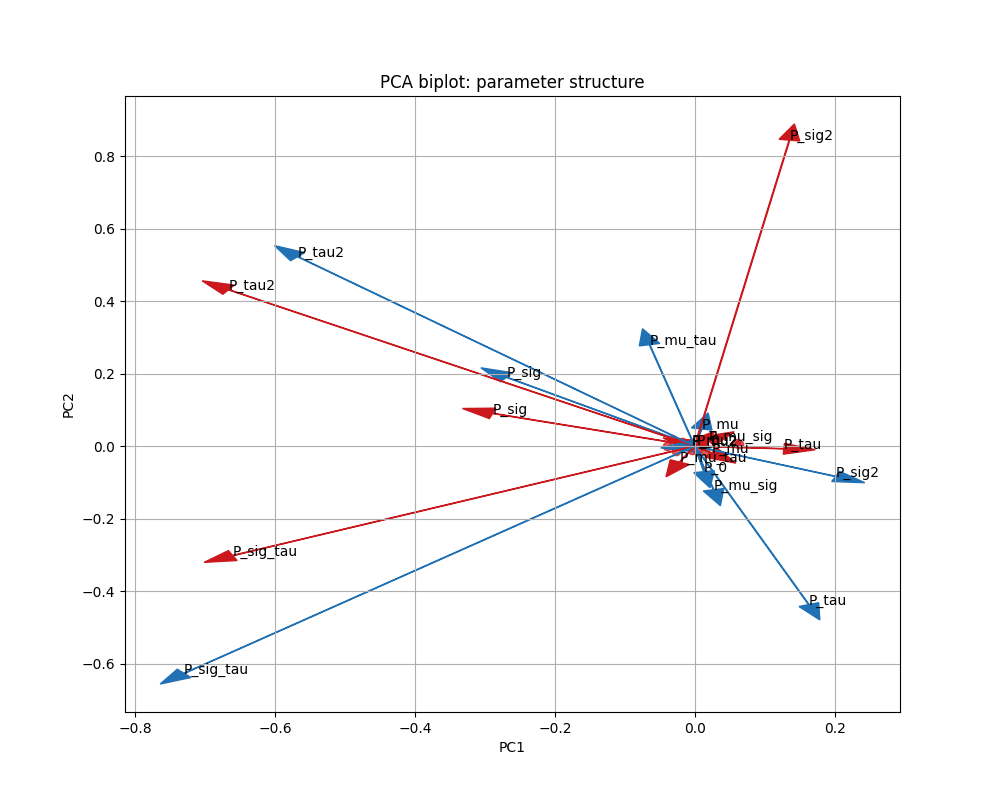

In [24]:
fig = plt.figure(figsize=(10,8))
plt.scatter(X_pca_FS[:,0], X_pca_FS[:,1], color = color_palette['FS'], alpha=0.7)
for i in range(n_params):
    plt.arrow(0, 0,
              loadings_FS[0,i],
              loadings_FS[1,i],
              head_width=0.03,
              color = color_palette['FS'])
    plt.text(loadings_FS[0,i],
             loadings_FS[1,i],
             f"{params_name[i]}")
    plt.arrow(0, 0,
              loadings_RS_no_adapt[0,i],
              loadings_RS_no_adapt[1,i],
              head_width=0.03,
              color = color_palette['RS_no_adapt'])
    plt.text(loadings_RS_no_adapt[0,i],
             loadings_RS_no_adapt[1,i],
             f"{params_name[i]}")    

plt.xlabel(f"PC1")
plt.ylabel(f"PC2")
plt.title("PCA biplot: parameter structure")
plt.grid()

figs.append(fig)

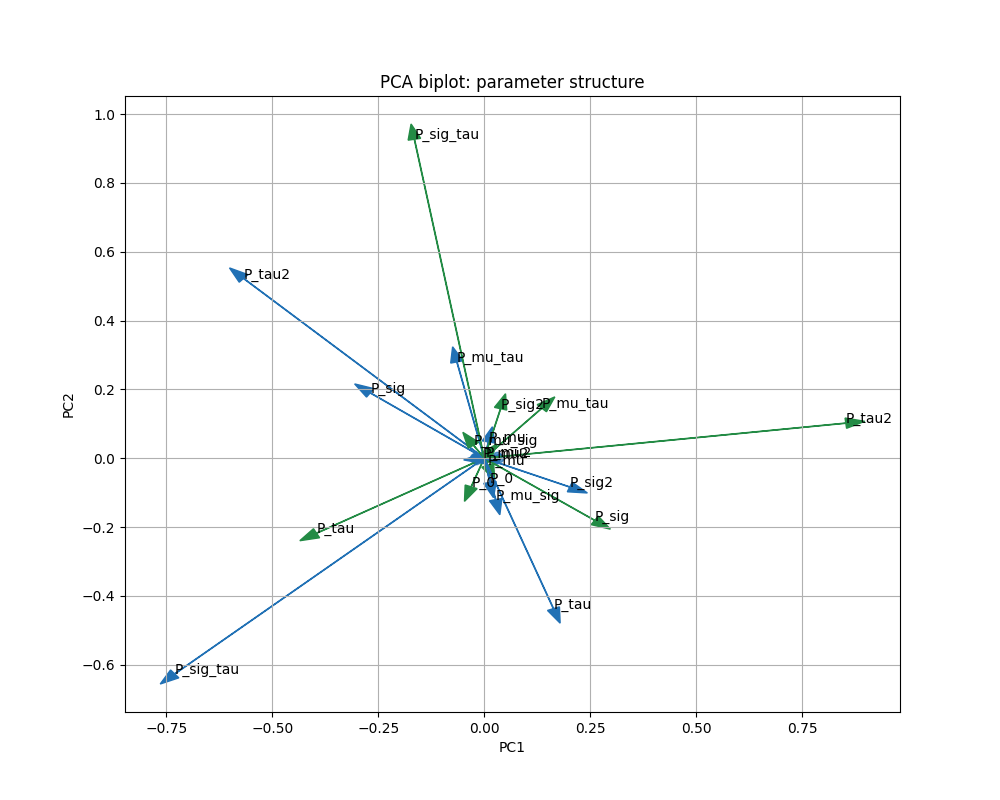

In [25]:
fig = plt.figure(figsize=(10,8))
plt.scatter(X_pca_RS_no_adapt[:,0], X_pca_RS_no_adapt[:,1], color = color_palette['RS_no_adapt'], alpha=0.7)
plt.scatter(X_pca_RS[:,0], X_pca_RS[:,1], color = color_palette['RS'], alpha=0.7)
for i in range(n_params):
    plt.arrow(0, 0,
              loadings_RS[0,i],
              loadings_RS[1,i],
              head_width=0.03,
              color = color_palette['RS'])
    plt.text(loadings_RS[0,i],
             loadings_RS[1,i],
             f"{params_name[i]}")
    plt.arrow(0, 0,
              loadings_RS_no_adapt[0,i],
              loadings_RS_no_adapt[1,i],
              head_width=0.03,
              color = color_palette['RS_no_adapt'])
    plt.text(loadings_RS_no_adapt[0,i],
             loadings_RS_no_adapt[1,i],
             f"{params_name[i]}")    

plt.xlabel(f"PC1")
plt.ylabel(f"PC2")
plt.title("PCA biplot: parameter structure")
plt.grid()

figs.append(fig)

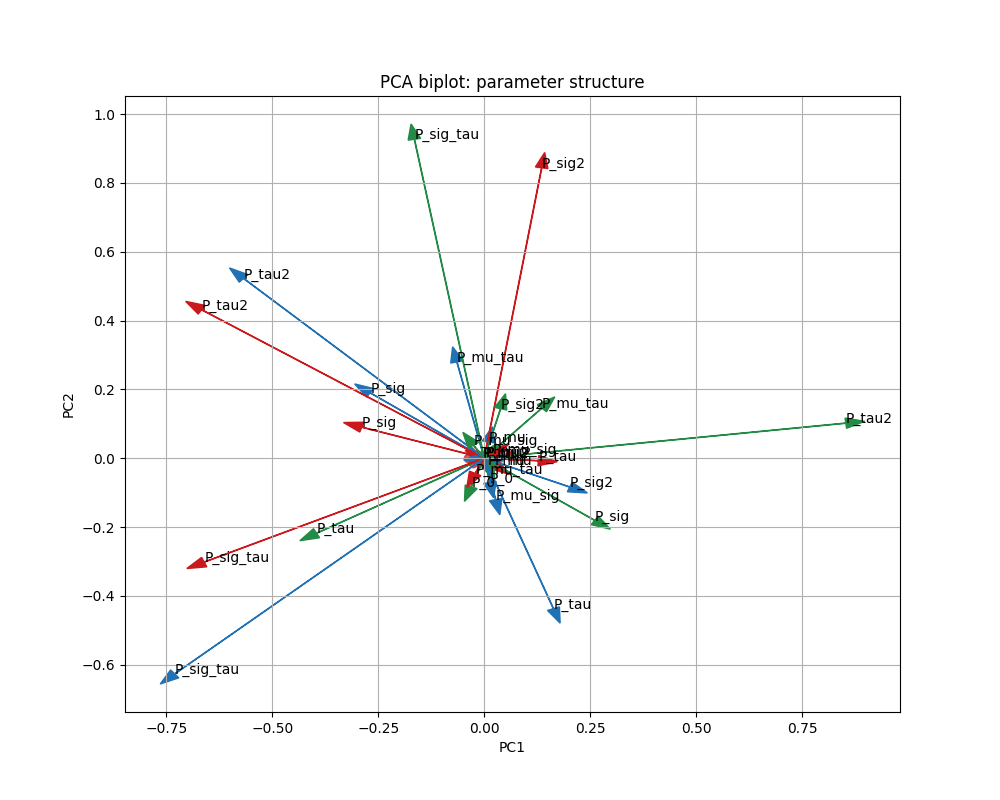

In [26]:
fig = plt.figure(figsize=(10,8))
plt.scatter(X_pca_FS[:,0], X_pca_FS[:,1], color = color_palette['FS'], alpha=0.7)
plt.scatter(X_pca_RS[:,0], X_pca_RS[:,1], color = color_palette['RS'], alpha=0.7)
plt.scatter(X_pca_RS_no_adapt[:,0], X_pca_RS_no_adapt[:,1], color = color_palette['RS_no_adapt'], alpha=0.7)

for i in range(n_params):
    plt.arrow(0, 0,
              loadings_FS[0,i],
              loadings_FS[1,i],
              head_width=0.03,
              color = color_palette['FS'])
    plt.text(loadings_FS[0,i],
             loadings_FS[1,i],
             f"{params_name[i]}")
    
    plt.arrow(0, 0,
              loadings_RS_no_adapt[0,i],
              loadings_RS_no_adapt[1,i],
              head_width=0.03,
              color = color_palette['RS_no_adapt'])
    plt.text(loadings_RS_no_adapt[0,i],
             loadings_RS_no_adapt[1,i],
             f"{params_name[i]}")  
    
    plt.arrow(0, 0,
              loadings_RS[0,i],
              loadings_RS[1,i],
              head_width=0.03,
              color = color_palette['RS'])
    plt.text(loadings_RS[0,i],
             loadings_RS[1,i],
             f"{params_name[i]}")      

plt.xlabel(f"PC1")
plt.ylabel(f"PC2")
plt.title("PCA biplot: parameter structure")
plt.grid()

figs.append(fig)

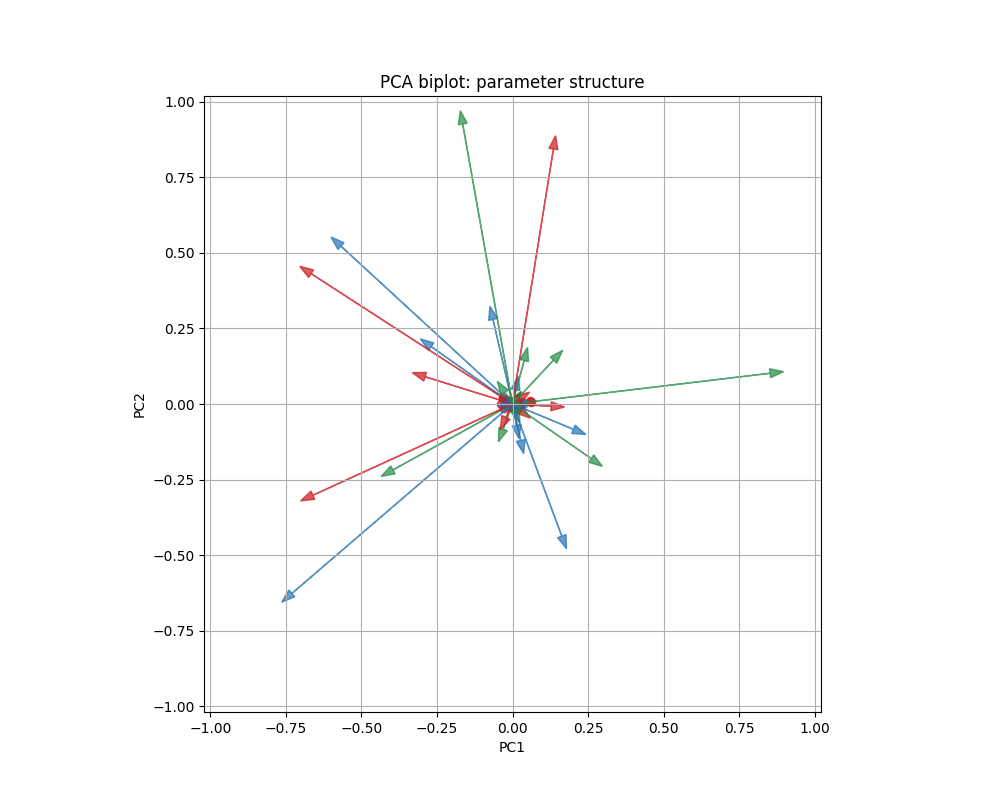

In [27]:
fig = plt.figure(figsize=(10, 8))
ax = plt.gca()

# --- Scores ---
ax.scatter(X_pca_FS[:,0], X_pca_FS[:,1],
           color=color_palette['FS'], alpha=0.7)
ax.scatter(X_pca_RS[:,0], X_pca_RS[:,1],
           color=color_palette['RS'], alpha=0.7)
ax.scatter(X_pca_RS_no_adapt[:,0], X_pca_RS_no_adapt[:,1],
           color=color_palette['RS_no_adapt'], alpha=0.7)

# --- Loadings ---
for i in range(n_params):
    ax.arrow(0, 0,
             loadings_FS[0,i], loadings_FS[1,i],
             head_width=0.03, color=color_palette['FS'], alpha=0.7)
    ax.arrow(0, 0,
             loadings_RS[0,i], loadings_RS[1,i],
             head_width=0.03, color=color_palette['RS'], alpha=0.7)
    ax.arrow(0, 0,
             loadings_RS_no_adapt[0,i], loadings_RS_no_adapt[1,i],
             head_width=0.03, color=color_palette['RS_no_adapt'], alpha=0.7)

# --- Axis control ---
all_x = np.concatenate([
    X_pca_FS[:,0], X_pca_RS[:,0], X_pca_RS_no_adapt[:,0],
    loadings_FS[0,:], loadings_RS[0,:], loadings_RS_no_adapt[0,:]
])
all_y = np.concatenate([
    X_pca_FS[:,1], X_pca_RS[:,1], X_pca_RS_no_adapt[:,1],
    loadings_FS[1,:], loadings_RS[1,:], loadings_RS_no_adapt[1,:]
])

lim = 1.1 * max(np.abs(all_x).max(), np.abs(all_y).max())

ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_aspect('equal', adjustable='box')

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA biplot: parameter structure")
ax.grid()

figs.append(fig)

In [28]:
save_figs(fig_path, fig_name, figs)